# ヒートインテグレーション ターゲティング — 動作確認ノートブック

`flowsheet/heat_integration.py` の動作を授業資料の例題で確認する。

**第一段階**として、BO ループ内で使う「targeting (理論限界)」だけを計算する:
- 最少加熱量 $Q_{H,\min}$ / 最少冷却量 $Q_{C,\min}$ — Problem Table Algorithm
- 与熱・受熱複合線、グランドコンポジットカーブ (GCC)
- 理想総伝熱面積 $A_{total}$ — Bath 式
- 最少熱交換器数 $N_{HE,\min}$ — Linnhoff 式
- ユーティリティ tier 別 Q 配分 (多 tier 対応、Linnhoff 標準手法)

ペアリング (どの流体とどの流体を熱交換させるか) は本モジュールでは行わない。
それは BO 終了後の post-processing (Stage 2) で扱う。

---

**参考文献**

[1] 長谷部 伸治, 外輪 健一郎『プロセスシステム工学 (No.4) — 熱交換器ネットワークの最適合成』京都大学 講義資料、令和7年度 (2025).
   §4.2 エクセルギー、§4.3 T-Q 線図、§4.4 最小接近温度差と最少必要加熱・冷却量、§4.5 熱複合線図の分解と最適システム合成、§4.6 エネルギー解析 (グランドコンポジットカーブ)、§4.7 詳細な検討。

[2] Linnhoff B., Hindmarsh E., "The pinch design method for heat exchanger networks," *Chem. Eng. Sci.* **38** (1983) 745–763. 多 tier 配分・最少 HE 数式の出典。


In [1]:
import os, sys
_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if _ROOT not in sys.path:
    sys.path.insert(0, _ROOT)

import matplotlib.pyplot as plt
import matplotlib
# Windows 日本語表示のためフォント設定
matplotlib.rcParams['font.family'] = ['Yu Gothic', 'Meiryo', 'MS Gothic', 'sans-serif']
matplotlib.rcParams['axes.unicode_minus'] = False

from flowsheet.heat_integration import (
    HIStream, UtilityTier, pinch_analysis, plot_TQ, plot_GCC,
)

def C(t_celsius):
    """°C → K"""
    return t_celsius + 273.15

print('準備完了')

準備完了


## 1. 教科書例題 4.2 の再現

教科書 p.4-7:

| ストリーム | 温度変化 [°C] | F·Cp [kW/K] | Q [kW] |
|---|---|---|---|
| 受熱 a | 40 → 90  | 3.0 | 150 |
| 受熱 b | 80 → 110 | 6.0 | 180 |
| 与熱 A | 125 → 80 | 4.0 | 180 |
| 与熱 B | 100 → 60 | 4.0 | 160 |

ΔTmin = 10°C のとき、教科書解答は **Q_H_min = 30 kJ/s = 30 kW**（蒸気 15 g/s）。

In [2]:
streams = [
    HIStream(name='a', T_in_K=C(40),  T_out_K=C(90),  F_Cp_kW_per_K=3.0),
    HIStream(name='b', T_in_K=C(80),  T_out_K=C(110), F_Cp_kW_per_K=6.0),
    HIStream(name='A', T_in_K=C(125), T_out_K=C(80),  F_Cp_kW_per_K=4.0),
    HIStream(name='B', T_in_K=C(100), T_out_K=C(60),  F_Cp_kW_per_K=4.0),
]

# 教科書例題 4.2 で使うユーティリティ
heating_tiers = [
    UtilityTier('LP Steam (140°C)', supply_T_K=C(140), jpy_per_GJ=1800, is_heating=True),
]
cooling_tiers = [
    UtilityTier('冷却水 (30°C)', supply_T_K=C(30), jpy_per_GJ=60, is_heating=False),
]

result = pinch_analysis(
    streams, dT_min_K=10.0,
    heating_tiers=heating_tiers, cooling_tiers=cooling_tiers,
)

print(f'feasible       : {result.feasible}')
print(f'Q_H_min        : {result.Q_H_min_kW:.2f} kW   (教科書解答 30 kW)')
print(f'Q_C_min        : {result.Q_C_min_kW:.2f} kW   (熱バランスから 40 kW)')
print(f'T_pinch (hot)  : {result.T_pinch_hot_K - 273.15:.1f} °C   (教科書 90°C)')
print(f'T_pinch (cold) : {result.T_pinch_cold_K - 273.15:.1f} °C  (教科書 80°C)')
print(f'A_total        : {result.A_total_m2:.2f} m²')
print(f'N_HE_min       : {result.N_HE_min}')
print(f'utility breakdown:')
for tier_name, Q in result.utility_breakdown.items():
    print(f'    {tier_name:<25s}: {Q:7.2f} kW')

feasible       : True
Q_H_min        : 30.00 kW   (教科書解答 30 kW)
Q_C_min        : 40.00 kW   (熱バランスから 40 kW)
T_pinch (hot)  : 90.0 °C   (教科書 90°C)
T_pinch (cold) : 80.0 °C  (教科書 80°C)
A_total        : 125.00 m²
N_HE_min       : 4
utility breakdown:
    LP Steam (140°C)         :   30.00 kW
    冷却水 (30°C)               :   40.00 kW


## 2. T-Q 線図（教科書 図 4.16 相当）

受熱複合線を Q_C_min だけ右にシフトして描いた標準形。

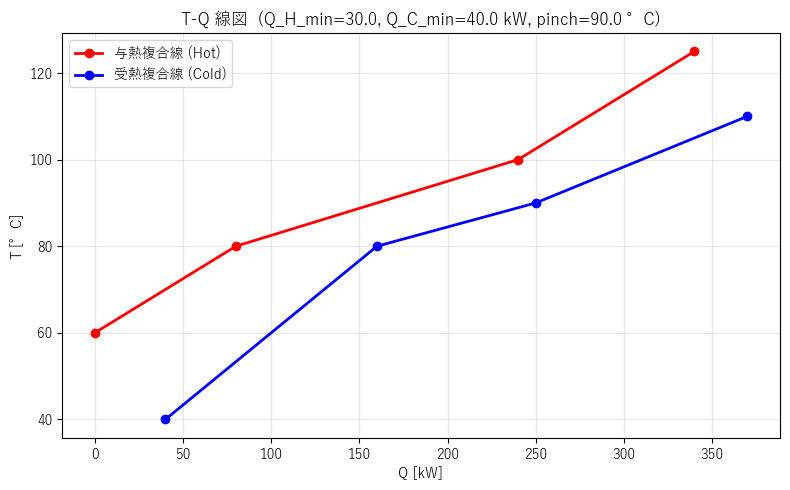

In [3]:
fig, ax = plt.subplots(figsize=(8, 5))
plot_TQ(result, ax=ax)
plt.tight_layout()
plt.show()

## 3. グランドコンポジットカーブ（教科書 図 4.27 相当）

縦軸はシフト温度（与熱 -ΔTmin/2、受熱 +ΔTmin/2 で揃えた温度）、横軸は H_residual。
GCC = 0 となる点がピンチ。

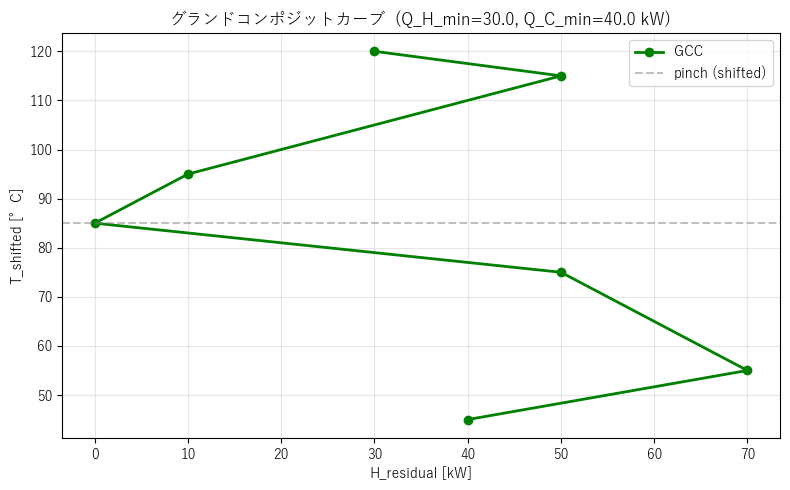

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))
plot_GCC(result, ax=ax)
plt.tight_layout()
plt.show()

## 4. ΔTmin 感度解析

ΔTmin を変えると Q_H_min / Q_C_min がどう変わるか。
ΔTmin が大きいほど熱回収は減り、外部加熱・冷却が必要になる（教科書 図 4.13）。

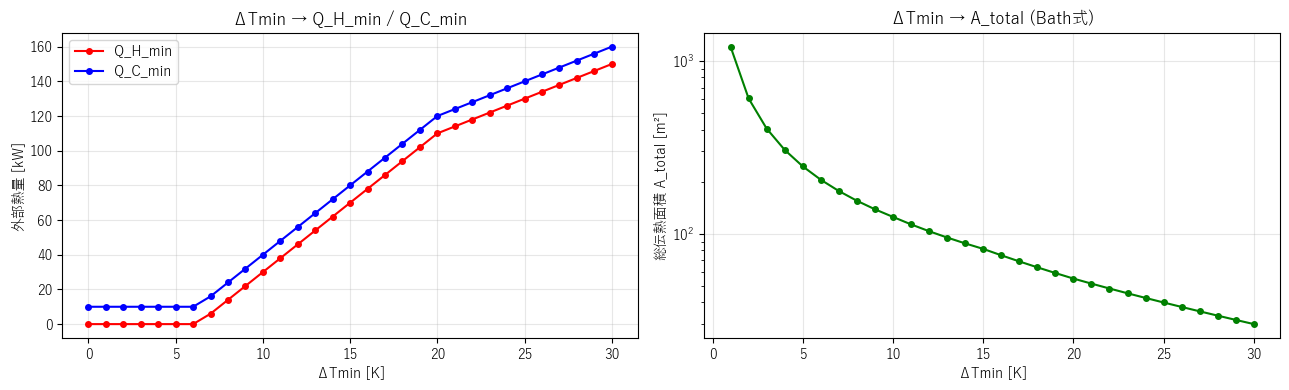

ΔTmin が小さい → 運転コスト削減 (Q_H_min↓) だが A_total↑ (建設コスト↑)
教科書 図 4.13 の運転コスト vs 建設コストのトレードオフが見える


In [5]:
import numpy as np

dT_list = np.linspace(0.0, 30.0, 31)
Q_H_list, Q_C_list, A_list = [], [], []
for dT in dT_list:
    r = pinch_analysis(streams, dT_min_K=float(dT))
    Q_H_list.append(r.Q_H_min_kW)
    Q_C_list.append(r.Q_C_min_kW)
    A_list.append(r.A_total_m2)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(dT_list, Q_H_list, 'r-o', label='Q_H_min', markersize=4)
axes[0].plot(dT_list, Q_C_list, 'b-o', label='Q_C_min', markersize=4)
axes[0].set_xlabel('ΔTmin [K]')
axes[0].set_ylabel('外部熱量 [kW]')
axes[0].set_title('ΔTmin → Q_H_min / Q_C_min')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(dT_list[1:], A_list[1:], 'g-o', markersize=4)   # ΔTmin=0 は発散
axes[1].set_xlabel('ΔTmin [K]')
axes[1].set_ylabel('総伝熱面積 A_total [m²]')
axes[1].set_title('ΔTmin → A_total (Bath式)')
axes[1].grid(True, alpha=0.3)
axes[1].set_yscale('log')

plt.tight_layout()
plt.show()

print('ΔTmin が小さい → 運転コスト削減 (Q_H_min↓) だが A_total↑ (建設コスト↑)')
print('教科書 図 4.13 の運転コスト vs 建設コストのトレードオフが見える')

## 5. 潜熱 (蒸気凝縮) を含むケース

教科書例題 4.2 では蒸気を「潜熱のみ・蒸発潜熱 2.0 kJ/g」として扱う。
本モジュールでも潜熱対応:

cold 必要加熱量 = 150.0 kW
steam 供給量    = 200 kW
Q_H_min         = 0.00 kW (cold 不足分)
Q_C_min         = 50.00 kW (steam 余剰)


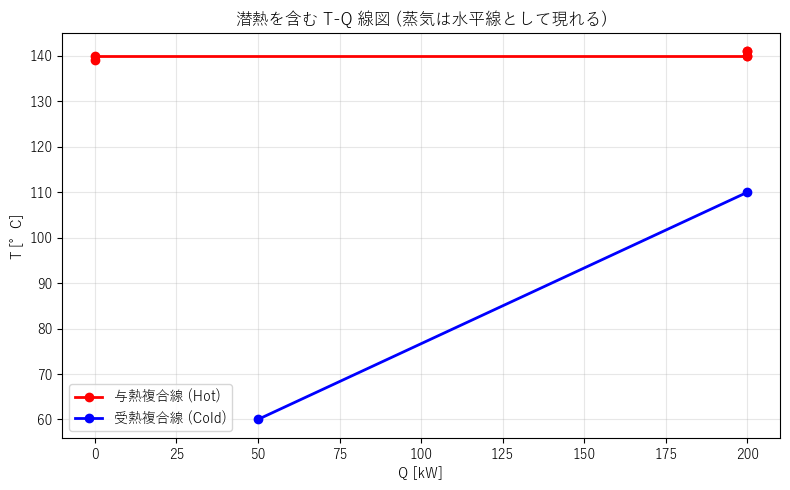

In [6]:
# 受熱 1 つ + 蒸気凝縮 (潜熱) で加熱
streams_latent = [
    HIStream(name='cold',  T_in_K=C(60),  T_out_K=C(110), F_Cp_kW_per_K=3.0),
    HIStream(name='steam', T_in_K=C(141), T_out_K=C(139), F_Cp_kW_per_K=0.0,
             Q_latent_kW=200.0, T_phase_K=C(140)),
]
result_latent = pinch_analysis(streams_latent, dT_min_K=10.0)
print(f'cold 必要加熱量 = {3.0 * (110-60)} kW')
print(f'steam 供給量    = 200 kW')
print(f'Q_H_min         = {result_latent.Q_H_min_kW:.2f} kW (cold 不足分)')
print(f'Q_C_min         = {result_latent.Q_C_min_kW:.2f} kW (steam 余剰)')

fig, ax = plt.subplots(figsize=(8, 5))
plot_TQ(result_latent, ax=ax)
ax.set_title('潜熱を含む T-Q 線図 (蒸気は水平線として現れる)')
plt.tight_layout()
plt.show()

## 6. PDH プロセスへの適用イメージ

現状の `run_one_pass.py` から自動抽出可能なストリーム:

| ID | 由来 | 種別 | 温度 [°C] |
|---|---|---|---|
| H1 | rx_out → cooled (反応器出口冷却) | 与熱 | ~600 → 30〜40 |
| H2 | intercool (圧縮段間冷却) | 与熱 | 断熱昇温温度 → 30〜40 |
| C1 | mem_precool (Mem 入口気化) | 受熱 | ~20 → mem_feed_K (潜熱含む) |
| C2 | reactor preheat | 受熱 | mix温 → ~600 |
| C3-C5 | Dist1/2/3 reboilers | 受熱 | 各塔底温度で潜熱 |
| H3-H5 | Dist1/2/3 condensers | 与熱 | 各塔頂温度で潜熱 |

次段階で `extract_streams(one_pass_result) -> List[HIStream]` を実装し、
実フローで `pinch_analysis` を呼ぶ。